<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/pivoting_rod_phase_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparison of the phase space of a uniform rigid rod with the one for a simple pendulum.

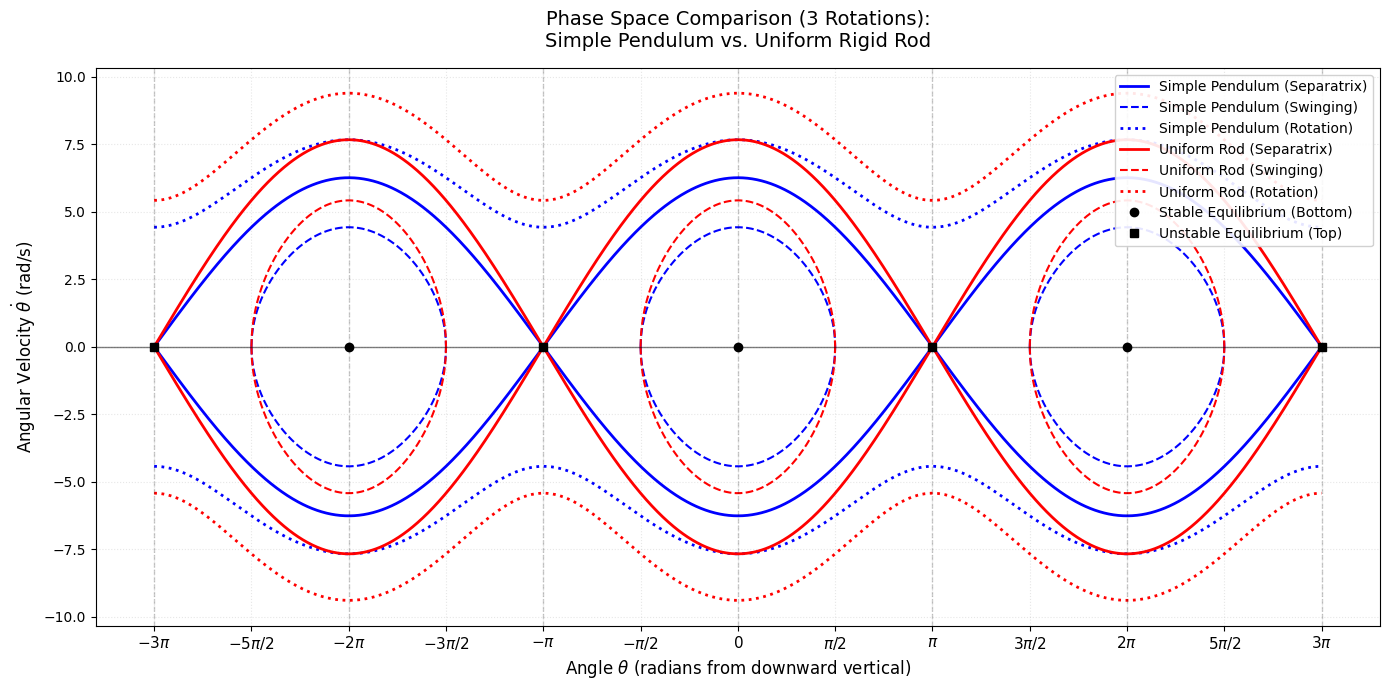

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_phase_trajectories(l=1.0, g=9.81):
    """
    Calculates the phase space trajectories (theta vs. omega) for both
    a simple pendulum and a uniform rigid rod of the same length and mass.
    """
    # Create an array of angles covering THREE full rotations (-3*pi to 3*pi)
    theta_sep = np.linspace(-3*np.pi, 3*np.pi, 1500)

    # ==========================================
    # 1. The Separatrix (Threshold of continuous rotation)
    # Energy required to just reach the top: E = mg * r_cm
    # ==========================================

    # Simple Pendulum: r_cm = l, I = ml^2
    omega_sep_simp = np.sqrt((2 * g / l) * (1 + np.cos(theta_sep)))

    # Uniform Rod: r_cm = l/2, I = (1/3)ml^2
    omega_sep_rod = np.sqrt((3 * g / l) * (1 + np.cos(theta_sep)))

    # ==========================================
    # 2. Inner Libration (Standard swinging)
    # Energy representing a release from the horizontal: E = 0
    # ==========================================

    # The pendulum only swings between -90 and 90 degrees for E=0
    theta_inner = np.linspace(-np.pi/2, np.pi/2, 500)

    # Simple Pendulum
    omega_in_simp = np.sqrt((2 * g / l) * np.cos(theta_inner))

    # Uniform Rod
    omega_in_rod = np.sqrt((3 * g / l) * np.cos(theta_inner))

    # ==========================================
    # 3. Outer Circulation (Continuous rotation)
    # Energy E = 2 * E_separatrix = 2 * mg * r_cm
    # ==========================================

    # Simple Pendulum
    omega_out_simp = np.sqrt((2 * g / l) * (2 + np.cos(theta_sep)))

    # Uniform Rod
    omega_out_rod = np.sqrt((3 * g / l) * (2 + np.cos(theta_sep)))

    return theta_sep, omega_sep_simp, omega_sep_rod, theta_inner, omega_in_simp, omega_in_rod, omega_out_simp, omega_out_rod

# ==========================================
# Plotting the Phase Space
# ==========================================
if __name__ == "__main__":
    # Get the trajectory data
    th_sep, om_sep_simp, om_sep_rod, th_in, om_in_simp, om_in_rod, om_out_simp, om_out_rod = calculate_phase_trajectories()

    # Made the figure slightly wider to better accommodate the extended 3-rotation range
    plt.figure(figsize=(14, 7))

    # ------------------------------------------
    # Plot Simple Pendulum Trajectories (Blue)
    # ------------------------------------------
    plt.plot(th_sep, om_sep_simp, 'b-', linewidth=2, label='Simple Pendulum (Separatrix)')
    plt.plot(th_sep, -om_sep_simp, 'b-', linewidth=2)

    # Swinging loops at center, -2pi, and +2pi
    plt.plot(th_in, om_in_simp, 'b--', linewidth=1.5, label='Simple Pendulum (Swinging)')
    plt.plot(th_in, -om_in_simp, 'b--', linewidth=1.5)
    plt.plot(th_in - 2*np.pi, om_in_simp, 'b--', linewidth=1.5)
    plt.plot(th_in - 2*np.pi, -om_in_simp, 'b--', linewidth=1.5)
    plt.plot(th_in + 2*np.pi, om_in_simp, 'b--', linewidth=1.5)
    plt.plot(th_in + 2*np.pi, -om_in_simp, 'b--', linewidth=1.5)

    plt.plot(th_sep, om_out_simp, 'b:', linewidth=2, label='Simple Pendulum (Rotation)')
    plt.plot(th_sep, -om_out_simp, 'b:', linewidth=2)

    # ------------------------------------------
    # Plot Uniform Rod Trajectories (Red)
    # ------------------------------------------
    plt.plot(th_sep, om_sep_rod, 'r-', linewidth=2, label='Uniform Rod (Separatrix)')
    plt.plot(th_sep, -om_sep_rod, 'r-', linewidth=2)

    # Swinging loops at center, -2pi, and +2pi
    plt.plot(th_in, om_in_rod, 'r--', linewidth=1.5, label='Uniform Rod (Swinging)')
    plt.plot(th_in, -om_in_rod, 'r--', linewidth=1.5)
    plt.plot(th_in - 2*np.pi, om_in_rod, 'r--', linewidth=1.5)
    plt.plot(th_in - 2*np.pi, -om_in_rod, 'r--', linewidth=1.5)
    plt.plot(th_in + 2*np.pi, om_in_rod, 'r--', linewidth=1.5)
    plt.plot(th_in + 2*np.pi, -om_in_rod, 'r--', linewidth=1.5)

    plt.plot(th_sep, om_out_rod, 'r:', linewidth=2, label='Uniform Rod (Rotation)')
    plt.plot(th_sep, -om_out_rod, 'r:', linewidth=2)

    # ------------------------------------------
    # Annotations and Formatting
    # ------------------------------------------
    # Mark the stable equilibrium points (0, and ±2pi)
    plt.plot([0, -2*np.pi, 2*np.pi], [0, 0, 0], 'ko', markersize=6, label='Stable Equilibrium (Bottom)')
    # Mark the unstable equilibrium points (±pi, ±3pi)
    plt.plot([-3*np.pi, -np.pi, np.pi, 3*np.pi], [0, 0, 0, 0], 'ks', markersize=6, label='Unstable Equilibrium (Top)')

    plt.title('Phase Space Comparison (3 Rotations):\nSimple Pendulum vs. Uniform Rigid Rod', fontsize=14, pad=15)
    plt.xlabel('Angle $\\theta$ (radians from downward vertical)', fontsize=12)
    plt.ylabel('Angular Velocity $\\dot{\\theta}$ (rad/s)', fontsize=12)

    # Set x-ticks to multiples of pi/2 across the new range
    plt.xticks(
        [-3*np.pi, -2.5*np.pi, -2*np.pi, -1.5*np.pi, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, 1.5*np.pi, 2*np.pi, 2.5*np.pi, 3*np.pi],
        ['$-3\\pi$', '$-5\\pi/2$', '$-2\\pi$', '$-3\\pi/2$', '$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$', '$3\\pi/2$', '$2\\pi$', '$5\\pi/2$', '$3\\pi$'],
        fontsize=11
    )

    # Axes lines and grid
    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    for x_line in [-3*np.pi, -2*np.pi, -np.pi, 0, np.pi, 2*np.pi, 3*np.pi]:
        plt.axvline(x_line, color='black', linewidth=1, alpha=0.2, linestyle='--')

    plt.grid(True, alpha=0.3, linestyle=':')

    # Place legend neatly out of the way
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.tight_layout()

    # Show the plot
    plt.show()